# Poisonous Mushrooms

In [12]:
import pandas as pd
import plotnine as p9

In [ ]:
columns = [
    "class",
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat",
]

mushroom_data = pd.read_csv(
    "tables/agaricus-lepiota.data.txt", header=None, names=columns
)

In [ ]:
class_map = {"e": "Edible", "p": "Poisonous"}
odor_map = {
    "a": "Almond",
    "l": "Anise",
    "c": "Creosote",
    "y": "Fishy",
    "f": "Foul",
    "m": "Musty",
    "n": "None",
    "p": "Pungent",
    "s": "Spicy",
}
spore_map = {
    "k": "Black",
    "n": "Brown",
    "b": "Buff",
    "h": "Chocolate",
    "r": "Green",
    "o": "Orange",
    "u": "Purple",
    "w": "White",
    "y": "Yellow",
}

mushroom_data["class_label"] = mushroom_data["class"].map(class_map)
mushroom_data["odor_label"] = mushroom_data["odor"].map(odor_map)
mushroom_data["spore_label"] = mushroom_data["spore-print-color"].map(spore_map)

print(mushroom_data[["class_label", "odor_label", "spore_label"]].head())

  class_label odor_label spore_label
0   Poisonous    Pungent       Black
1      Edible     Almond       Brown
2      Edible      Anise       Brown
3   Poisonous    Pungent       Black
4      Edible       None       Brown


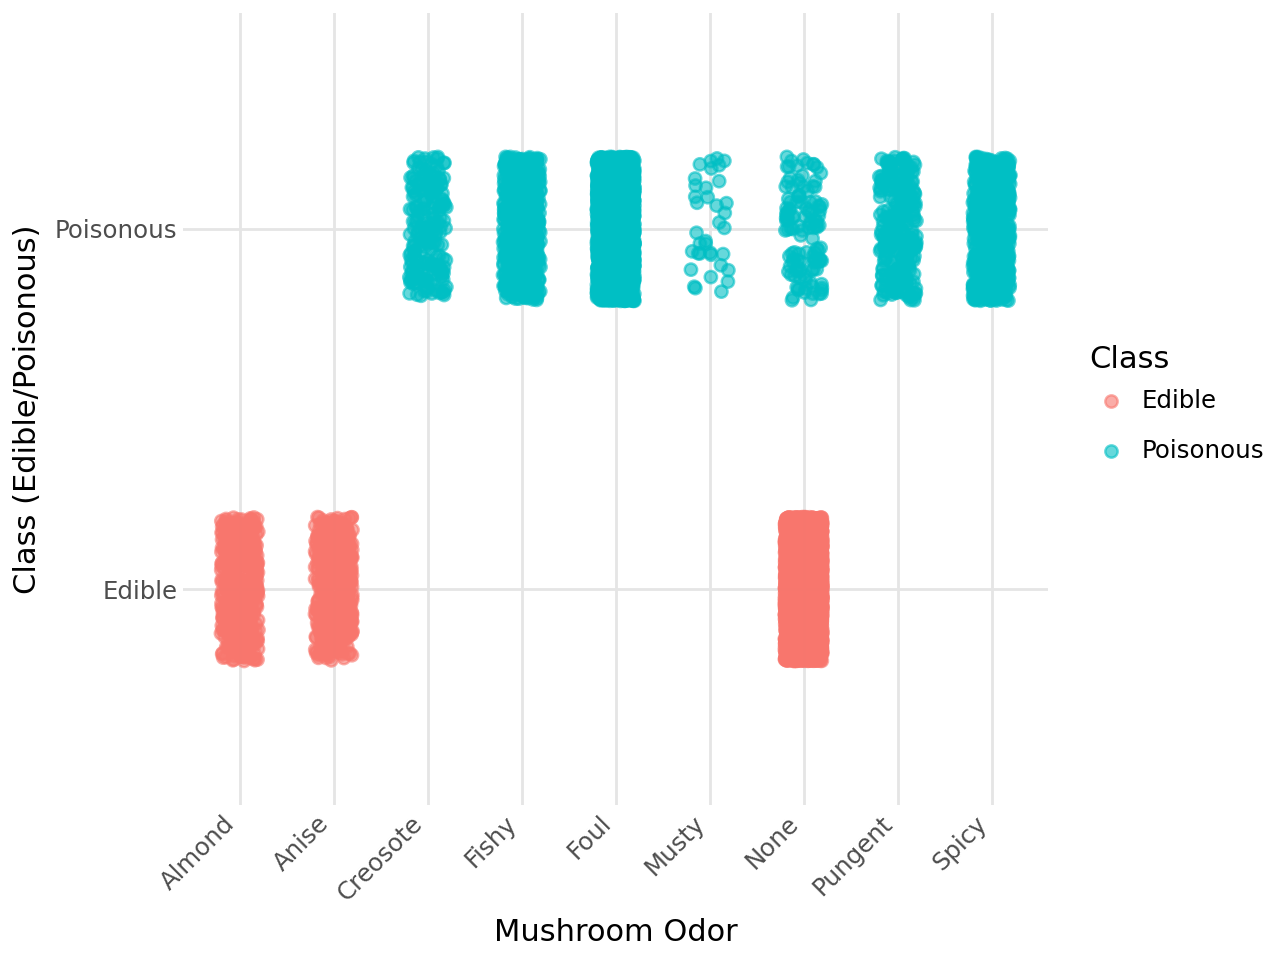

In [ ]:
plot_odor = (
    p9.ggplot(
        mushroom_data, p9.aes(x="odor_label", y="class_label", color="class_label")
    )
    + p9.geom_jitter(width=0.2, height=0.2, alpha=0.6, size=2)
    + p9.labs(x="Mushroom Odor", y="Class (Edible/Poisonous)", color="Class")
    + p9.theme_minimal()
    + p9.theme(axis_text_x=p9.element_text(rotation=45, ha="right"))
)

plot_odor

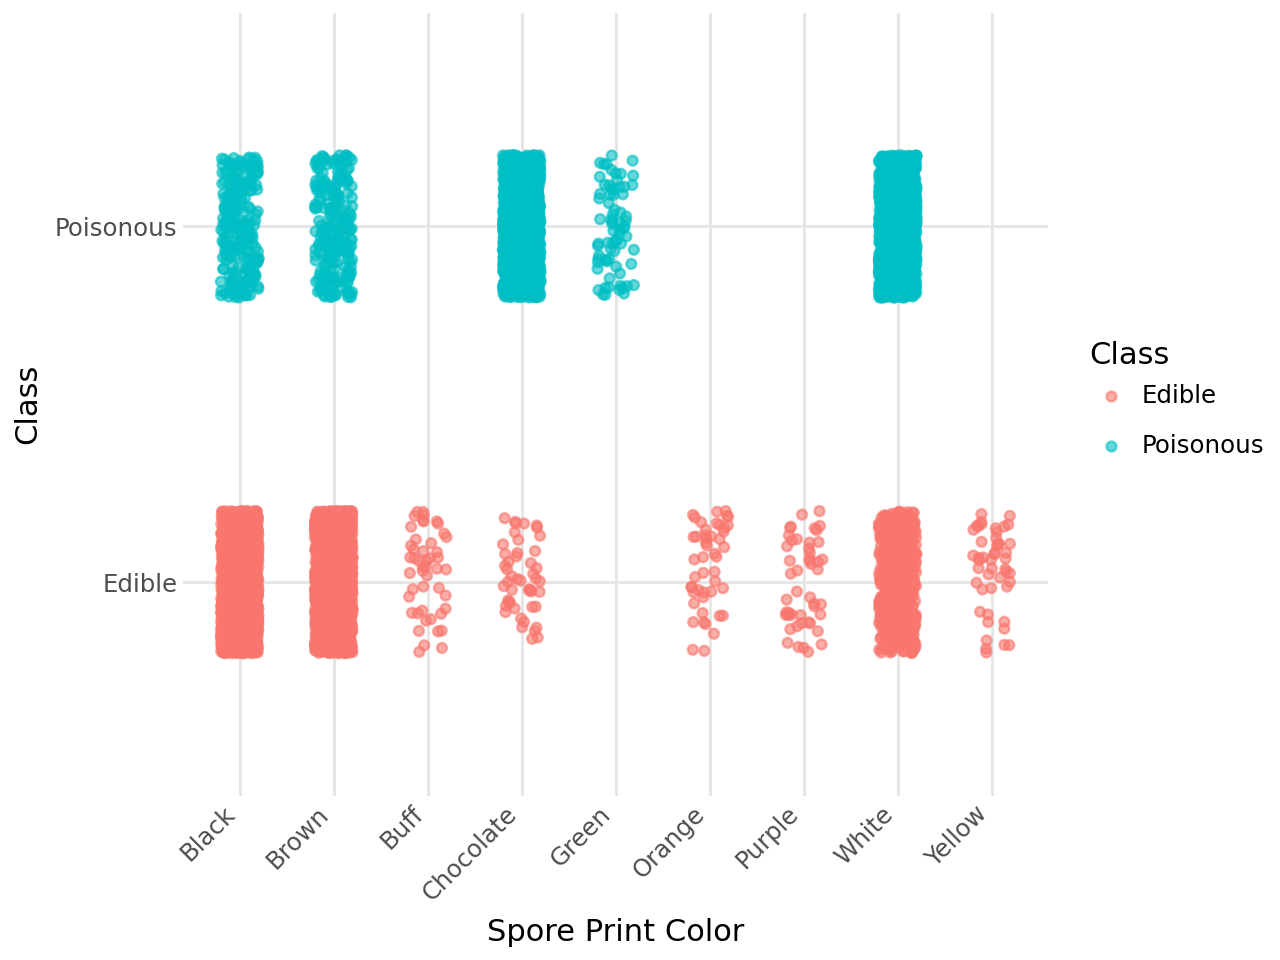

In [ ]:
plot_spore = (
    p9.ggplot(
        mushroom_data, p9.aes(x="spore_label", y="class_label", color="class_label")
    )
    + p9.geom_jitter(width=0.2, height=0.2, alpha=0.6)
    + p9.labs(x="Spore Print Color", y="Class", color="Class")
    + p9.theme_minimal()
    + p9.theme(axis_text_x=p9.element_text(rotation=45, ha="right"))
)


plot_spore

In [ ]:
gill_color_map = {
    "k": "Black",
    "n": "Brown",
    "b": "Buff",
    "h": "Chocolate",
    "g": "Gray",
    "r": "Green",
    "o": "Orange",
    "p": "Pink",
    "u": "Purple",
    "e": "Red",
    "w": "White",
    "y": "Yellow",
}

habitat_map = {
    "g": "Grasses",
    "l": "Leaves",
    "m": "Meadows",
    "p": "Paths",
    "u": "Urban",
    "w": "Waste",
    "d": "Woods",
}

cap_color_map = {
    "n": "Brown",
    "b": "Buff",
    "c": "Cinnamon",
    "g": "Gray",
    "r": "Green",
    "p": "Pink",
    "u": "Purple",
    "e": "Red",
    "w": "White",
    "y": "Yellow",
}

mushroom_data["gill_color_label"] = mushroom_data["gill-color"].map(gill_color_map)
mushroom_data["habitat_label"] = mushroom_data["habitat"].map(habitat_map)
mushroom_data["cap_color_label"] = mushroom_data["cap-color"].map(cap_color_map)

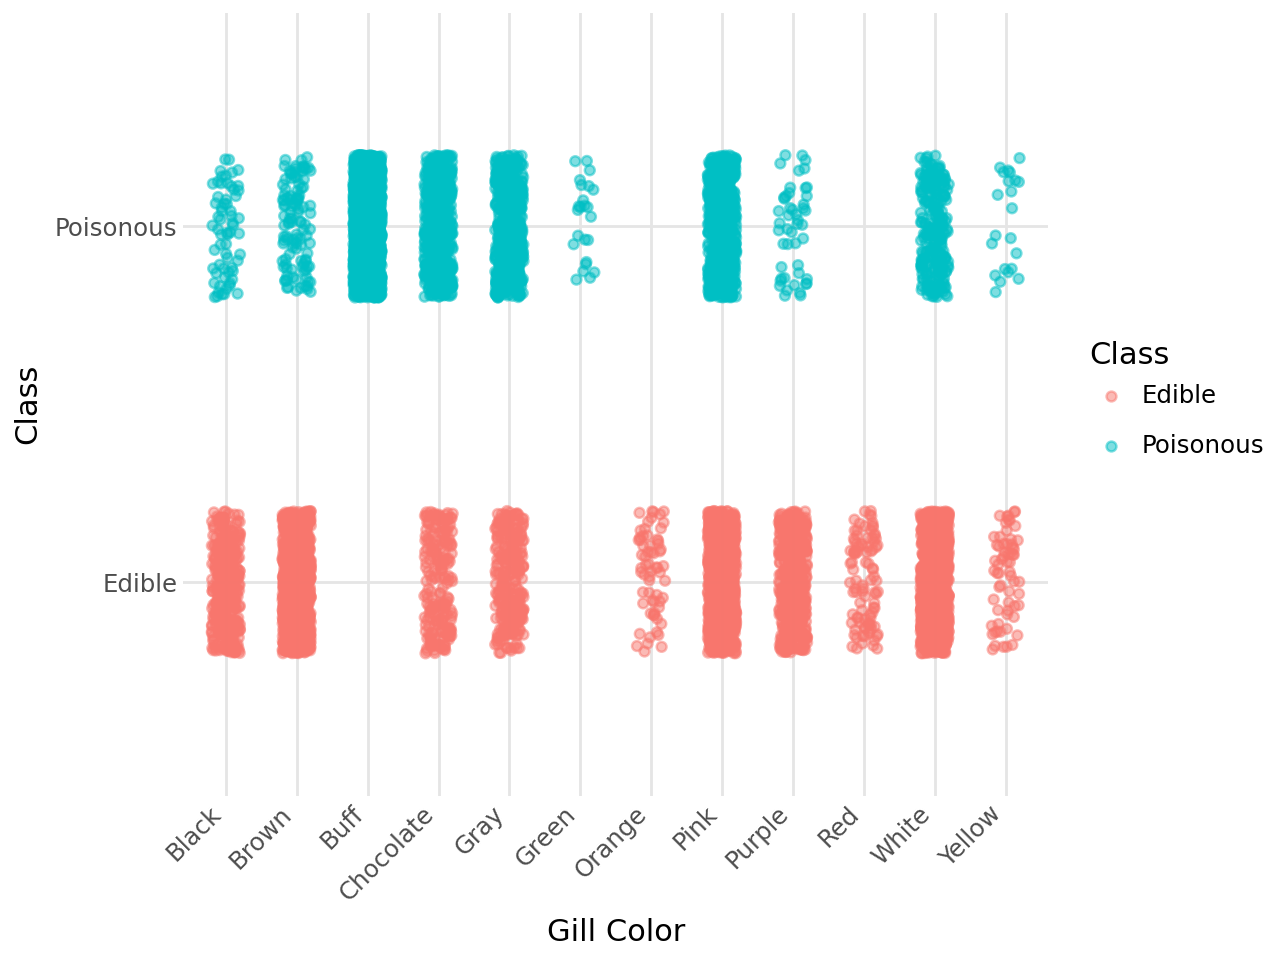

In [33]:
plot_gill = (
    p9.ggplot(
        mushroom_data,
        p9.aes(x="gill_color_label", y="class_label", color="class_label"),
    )
    + p9.geom_jitter(width=0.2, height=0.2, alpha=0.5)
    + p9.labs(x="Gill Color", y="Class", color="Class")
    + p9.theme_minimal()
    + p9.theme(axis_text_x=p9.element_text(rotation=45, ha="right"))
)

plot_gill

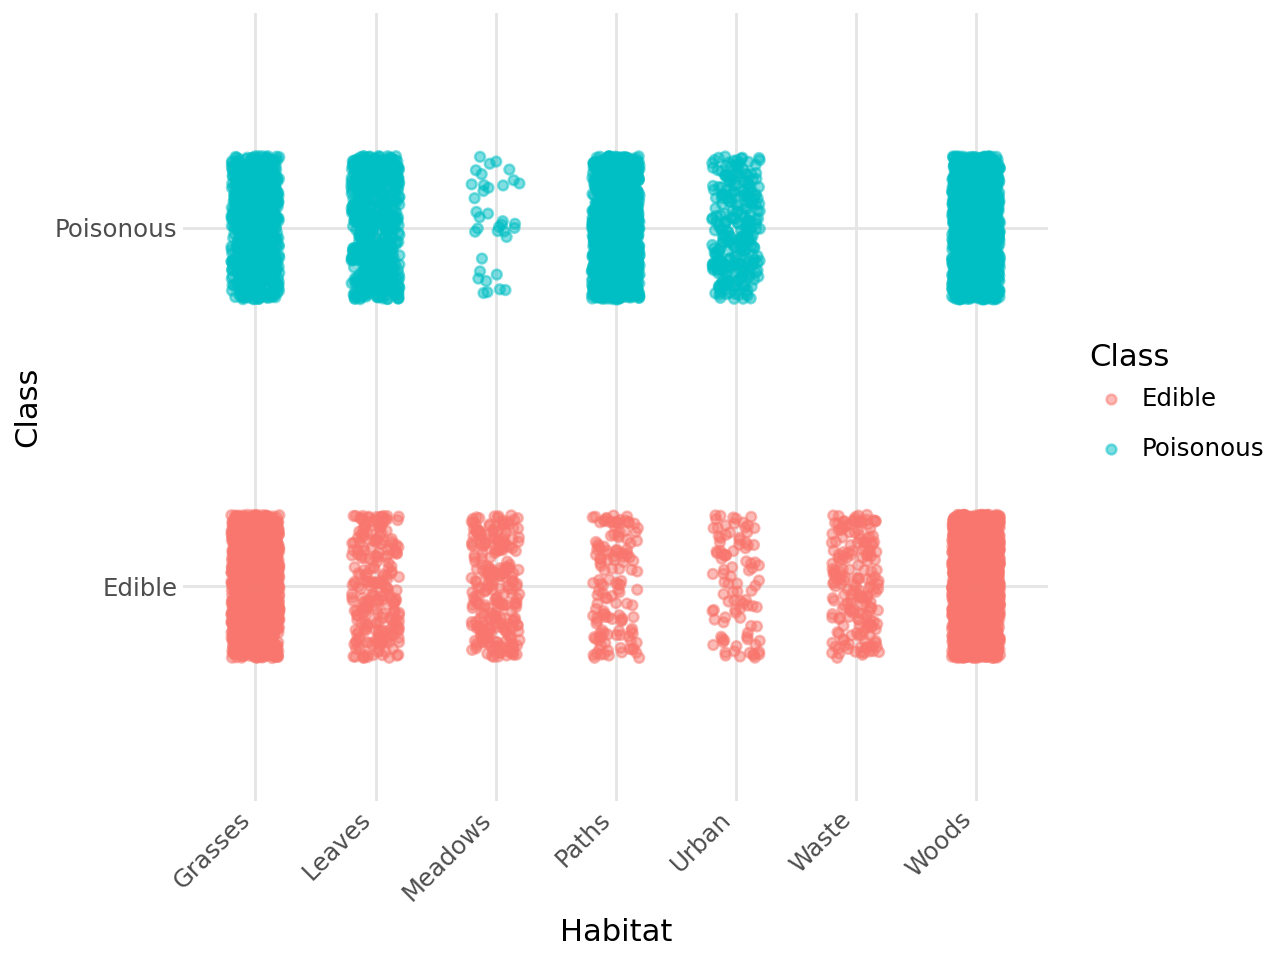

In [34]:
plot_habitat = (
    p9.ggplot(
        mushroom_data, p9.aes(x="habitat_label", y="class_label", color="class_label")
    )
    + p9.geom_jitter(width=0.2, height=0.2, alpha=0.5)
    + p9.labs(
        x="Habitat",
        y="Class",
        color="Class",
    )
    + p9.theme_minimal()
    + p9.theme(axis_text_x=p9.element_text(rotation=45, ha="right"))
)

plot_habitat

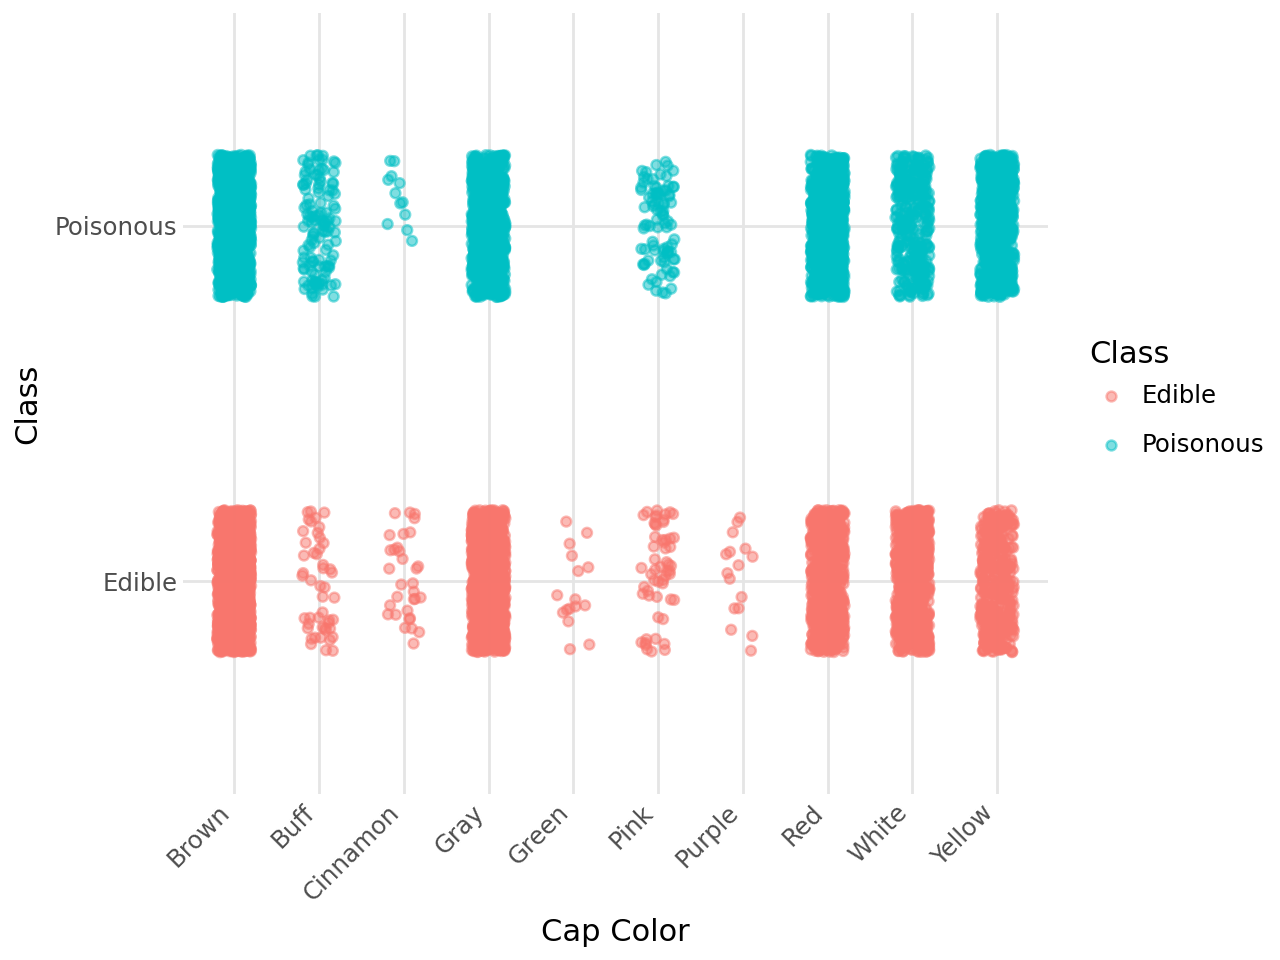

In [35]:
plot_cap = (
    p9.ggplot(
        mushroom_data, p9.aes(x="cap_color_label", y="class_label", color="class_label")
    )
    + p9.geom_jitter(width=0.2, height=0.2, alpha=0.5)
    + p9.labs(
        x="Cap Color",
        y="Class",
        color="Class",
    )
    + p9.theme_minimal()
    + p9.theme(axis_text_x=p9.element_text(rotation=45, ha="right"))
)

plot_cap

Rule of Thumb:

1. The Golden Rule (Odor): Sniff it first! If it smells like Almond or Anise, it is edible. If it smells like anything unpleasant (foul, fishy, spicy), drop it.

2. The Second Check (Spore Print Color): Placing the cap on paper (white and black for contrast), covering it to maintain humidity, and leaving it for several hours or overnight. If the color is Green, it is poisonous. If the color is buff, orange, yellow, or purple, it is edible.

3. The Third Check (Gills): Turn the mushroom over. If the gills are Buff (beige) or Green, it is poisonous. If it is orange or red, it is edible.

4. The Location Warning (Habitat): Be extremely suspicious of mushrooms found growing along everywhere except waste.

5. The Myth Buster (Cap Color): Do not trust the cap color. White, Brown, and Red mushrooms can be deadly. Never use color as your primary guide.